# 🔗 STACKING MULTIMODAL — Fusión CXR + ECG + Laboratorio (CPU)
## TFM · Sistema de Apoyo a la Decisión Clínica Multimodal · Fusión tardía
### Universidad de Salamanca · Máster en Análisis Avanzado de Datos Multivariantes y Big Data

---

## 🎯 Qué hace

Combina las predicciones de los **tres modelos por modalidad** (imagen, ECG, analíticas) con un **meta-modelo**
que aprende **cuánto pesa cada modalidad para cada enfermedad**. Se prueban **dos meta-modelos**: **Regresión
Logística** (L2) y **XGBoost** (poco profundo), y se comparan contra el **blending** (promedio) y contra el
**mejor modelo individual** (CXR).

## 🧱 Modelos base (mejor versión de cada modalidad, elegida por sus resultados reales)

| Modalidad | Versión usada | Macro AUC | De dónde salen las predicciones |
|---|---|---|---|
| **CXR** | **v5** (la mejor; v6.1/v6.2 salieron peor) | 0.809 | Se **cargan** sus CSV OOF/val/test ya exportados |
| **ECG** | **v3.1** (ResNet1D base 48, señal 1250) | 0.629 | Se **regeneran** por K-fold (prep cacheado) |
| **LABS** | **blend local v2.2** (XGB+LGB+LogReg+MLP) | ~0.69 | Se **regeneran** por K-fold (sin TabPFN nube) |

## ⚠️ Lo más importante: predicciones OUT-OF-FOLD (sin data leakage)

El meta-modelo NO puede entrenarse con predicciones de modelos que vieron esos datos. Por eso:
- Para **train** se usan predicciones **out-of-fold (OOF)**: cada muestra la predice un modelo que **no la vio**.
- Para **test** los modelos base se reentrenan en **todo el train** y predicen test (test queda **100% limpio**).
- El rendimiento del meta-modelo se estima con **K-fold sobre las OOF** (no con el mismo train que las generó).

## 🧠 Entrada del meta-modelo

**18 probabilidades** (6 etiquetas × 3 modalidades) **+ contexto clínico** (edad, sexo, raza, tipo y lugar de
ingreso, horas). El meta aprende, p. ej., que para Cardiomegaly el ECG/LABS aportan, y para Atelectasis manda la imagen.

## 🩻 Se respetan todas las reglas de las modalidades

Masking de NaN/−1 intacto · negativos derivados por exclusividad (No Finding) · desequilibrio por etiqueta · AUC-ROC macro.

## ⏱️ Coste (CPU): el OOF del ECG es lo único pesado (~2 h). `FAST_MODE=True` lo reduce a una prueba rápida.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"],check=True)
for pkg in ["xgboost","lightgbm","scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"],check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / CONSTANTES
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4); DEVICE=torch.device("cpu")

NB=Path.cwd()
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
CXR_OOF=NB/"outputs_cxr_densenet121_v5"          # de aquí cargo los CSV OOF/val/test de CXR (mejor versión)
ECG_PREP=NB/"outputs_ecg_resnet1d_v3_1"/"prep"   # prep cacheado del ECG (v3.1, señal 1250)
ECG_LEN=1250; ECG_BASE=48; ECG_BLOCKS=2; N_LEADS=12
OUT=NB/"outputs_stacking"; OUT.mkdir(parents=True,exist_ok=True)
FIG=OUT/"figuras"; FIG.mkdir(parents=True,exist_ok=True)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
MODALITIES=["CXR","ECG","LABS"]
FAST_MODE=False
K_OOF=5 if not FAST_MODE else 3
ECG_EPOCHS=18 if not FAST_MODE else 5; ECG_PATIENCE=4; ECG_BATCH=64
LABS_FLAG_THRESH=0.02
GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}; RACE_ONEHOT=5
print(f"Stacking · K_OOF={K_OOF} · FAST_MODE={FAST_MODE} · {DEVICE}")
print(f"CXR OOF dir existe: {CXR_OOF.exists()} · ECG prep existe: {ECG_PREP.exists()}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Stacking · K_OOF=5 · FAST_MODE=False · cpu
CXR OOF dir existe: True · ECG prep existe: True


In [3]:
# CELDA 3 · CARGA, OBJETIVOS (masking + negativos derivados) Y CONTEXTO
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
def build_targets(df,uncertainty_policy="zeros",derive=True):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0
    return labels,mask
y_train,m_train=build_targets(df_train); y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)
def build_context(df):
    N=len(df); cols=[]; names=[]
    AGEMIN,AGEMAX=float(df_train["age"].min()),float(df_train["age"].max())
    HMIN,HMAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())
    cols.append(((df["age"].astype(float)-AGEMIN)/(AGEMAX-AGEMIN+1e-8)).to_numpy()[:,None]); names.append("Edad")
    cols.append(df["gender"].map(lambda v:float(GENDER_MAP.get(v,0))).to_numpy()[:,None]); names.append("Sexo")
    def oh(series,mp,pref):
        M=np.zeros((N,max(mp.values())+1),np.float32)
        for i,v in enumerate(series): M[i,mp.get(str(v).upper(),0)]=1.0
        return M,[f"{pref}={k}" for k,_ in sorted(mp.items(),key=lambda x:x[1])][:M.shape[1]]
    for col,mp,pref in [("race",RACE_MAP,"Raza"),("admission_type",ADMISSION_MAP,"Ingreso"),("admission_location",ADM_LOC_MAP,"Lugar")]:
        M,nm=oh(df[col],mp,pref); cols.append(M); names+=nm
    cols.append(((df["hours_adm_to_cxr"].astype(float)-HMIN)/(HMAX-HMIN+1e-8)).to_numpy()[:,None]); names.append("Horas")
    return np.hstack(cols).astype(np.float32),names
CTX_tr,CTX_NAMES=build_context(df_train); CTX_vl,_=build_context(df_val); CTX_te,_=build_context(df_test)
print(f"train={len(df_train)} val={len(df_val)} test={len(df_test)} · contexto={CTX_tr.shape[1]} dims")


train=10000 val=750 test=464 · contexto=16 dims


In [4]:
# CELDA 4 · MÉTRICAS
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum()); fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"n_pos":npos,"n_neg":nneg,"thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
def dyn_pos_weight(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return w
print("Métricas listas.")


Métricas listas.


In [5]:
# CELDA 5 · CXR — cargar predicciones OOF/val/test (mejor versión v5) y alinear por hadm_id
def load_cxr(csv):
    d=pd.read_csv(csv).set_index("hadm_id")
    cols=[f"cxr_{l.replace(' ','_')}_cal" for l in LABELS]
    return d[cols]
cxr_oof_df=load_cxr(CXR_OOF/"cxr_pred_oof_train.csv")
cxr_val_df=load_cxr(CXR_OOF/"cxr_pred_val.csv")
cxr_test_df=load_cxr(CXR_OOF/"cxr_pred_test.csv")
def align(df_idx, pred_df):
    out=pred_df.reindex(df_idx["hadm_id"].to_numpy())
    miss=out.isna().any(axis=1).sum()
    if miss>0: print(f"   ⚠ {miss} hadm_id sin predicción CXR (se rellenan con 0.5)"); out=out.fillna(0.5)
    return out.to_numpy(np.float32)
CXR_oof=align(df_train,cxr_oof_df); CXR_vl=align(df_val,cxr_val_df); CXR_te=align(df_test,cxr_test_df)
print(f"CXR cargado · OOF={CXR_oof.shape} val={CXR_vl.shape} test={CXR_te.shape}")
print("   CXR OOF macro (sanity):", round(multilabel_metrics(CXR_oof,y_train,m_train)["macro_AUC_path"],4))


CXR cargado · OOF=(10000, 6) val=(750, 6) test=(464, 6)
   CXR OOF macro (sanity): 0.7858


In [6]:
# CELDA 6 · LABS — generar OOF/val/test con blend local (XGB+LGB+LogReg+MLP), sin leakage
DEMO=["subject_id","hadm_id","cxr_path","ecg_path","age","gender","race","admission_type","admission_location","cxr_view","hours_adm_to_cxr"]
RAW_LABS=[c for c in df_train.columns if c not in LABELS and c not in DEMO and "pctile" not in c]
PCT_LABS=[c for c in df_train.columns if "pctile" in c]
tm=df_train[RAW_LABS].isna().mean(); FLAG_LABS=[c for c in RAW_LABS if tm[c]>LABS_FLAG_THRESH]
def lab_tree(df): return np.hstack([df[RAW_LABS].to_numpy(np.float32), df[FLAG_LABS].isna().astype(np.float32).to_numpy(), CTX_of(df)])
def lab_dense(df): return np.hstack([df[PCT_LABS].to_numpy(np.float32), df[FLAG_LABS].isna().astype(np.float32).to_numpy(), CTX_of(df)])
def CTX_of(df):
    return build_context(df)[0]
TREE_tr=lab_tree(df_train); TREE_vl=lab_tree(df_val); TREE_te=lab_tree(df_test)
DENSE_tr=lab_dense(df_train); DENSE_vl=lab_dense(df_val); DENSE_te=lab_dense(df_test)
def dfit(idx):
    imp=SimpleImputer(strategy="median").fit(DENSE_tr[idx]); sc=StandardScaler().fit(imp.transform(DENSE_tr[idx])); return imp,sc
def dtx(imp,sc,X): return sc.transform(imp.transform(X)).astype(np.float32)
def ovr(make,Xtr,ytr,mtr,Xva,spw=True):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2: P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        w=(yj==0).sum()/max((yj==1).sum(),1); clf=make(w if spw else None); clf.fit(Xj,yj); P[:,j]=clf.predict_proba(Xva)[:,1]
    return P
mk_xgb=lambda w: xgb.XGBClassifier(n_estimators=600,max_depth=4,learning_rate=0.04,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.5,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED,scale_pos_weight=w)
mk_lgb=lambda w: lgb.LGBMClassifier(n_estimators=600,num_leaves=48,learning_rate=0.04,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.5,n_jobs=4,random_state=SEED,verbosity=-1,scale_pos_weight=w)
mk_lr =lambda w: LogisticRegression(max_iter=3000,class_weight="balanced",C=1.0,n_jobs=4)
class TabMLP(nn.Module):
    def __init__(s,d):
        super().__init__(); s.n=nn.Sequential(nn.Linear(d,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(0.4),nn.Linear(256,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(0.3),nn.Linear(128,N_LABELS))
    def forward(s,x): return s.n(x)
def train_labmlp(Xtr,ytr,mtr,Xva,epochs=80,patience=10,yva=None,mva=None):
    pw=torch.tensor(dyn_pos_weight(ytr,mtr)); model=TabMLP(Xtr.shape[1]).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=8e-4,weight_decay=1e-4); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs,1e-7)
    Xt=torch.tensor(Xtr); Yt=torch.tensor(ytr); Mt=torch.tensor(mtr); n=len(Xt); best,bs,wait=-1,None,0
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n)
        for i in range(0,n,256):
            idx=perm[i:i+256]
            if len(idx)<2: continue
            opt.zero_grad(); lo=model(Xt[idx].to(DEVICE)); bce=F.binary_cross_entropy_with_logits(lo,Yt[idx].to(DEVICE),pos_weight=pw.to(DEVICE),reduction="none")*Mt[idx].to(DEVICE)
            loss=bce.sum()/Mt[idx].sum().clamp(min=1e-8); loss.backward(); opt.step()
        sch.step()
        with torch.no_grad():
            model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
        if yva is not None:
            sc=multilabel_metrics(pv,yva,mva)["macro_AUC_path"]
            if sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(model.state_dict()),0
            else:
                wait+=1
                if wait>=patience: break
    if bs is not None: model.load_state_dict(bs)
    with torch.no_grad():
        model.eval(); return torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()

def labs_blend(idx_tr, Xtree_va, Xdense_va_raw, imp, sc, yva=None, mva=None):
    p=[ovr(mk_xgb,TREE_tr[idx_tr],y_train[idx_tr],m_train[idx_tr],Xtree_va),
       ovr(mk_lgb,TREE_tr[idx_tr],y_train[idx_tr],m_train[idx_tr],Xtree_va),
       ovr(mk_lr ,dtx(imp,sc,DENSE_tr[idx_tr]),y_train[idx_tr],m_train[idx_tr],dtx(imp,sc,Xdense_va_raw),spw=False),
       train_labmlp(dtx(imp,sc,DENSE_tr[idx_tr]),y_train[idx_tr],m_train[idx_tr],dtx(imp,sc,Xdense_va_raw),yva=yva,mva=mva)]
    return np.mean(p,axis=0)

print("Generando OOF de LABS (blend local, K-fold)...")
LABS_oof=np.zeros((len(df_train),N_LABELS),np.float32); kf=KFold(K_OOF,shuffle=True,random_state=SEED); t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    imp,sc=dfit(tr); LABS_oof[va]=labs_blend(tr,TREE_tr[va],DENSE_tr[va],imp,sc); print(f"   LABS fold {k+1}/{K_OOF} ({(time.time()-t0)/60:.1f} min)")
imp_f,sc_f=dfit(np.arange(len(df_train)))
LABS_vl=labs_blend(np.arange(len(df_train)),TREE_vl,DENSE_vl,imp_f,sc_f)
LABS_te=labs_blend(np.arange(len(df_train)),TREE_te,DENSE_te,imp_f,sc_f)
print(f"LABS listo ({(time.time()-t0)/60:.1f} min) · OOF macro:",round(multilabel_metrics(LABS_oof,y_train,m_train)["macro_AUC_path"],4))


Generando OOF de LABS (blend local, K-fold)...
   LABS fold 1/5 (2.4 min)
   LABS fold 2/5 (5.0 min)
   LABS fold 3/5 (7.8 min)
   LABS fold 4/5 (9.9 min)
   LABS fold 5/5 (11.7 min)
LABS listo (15.6 min) · OOF macro: 0.6687


In [7]:
# CELDA 7 · ECG — generar OOF/val/test (ResNet1D v3.1, prep cacheado), sin leakage
Xe_tr=np.load(ECG_PREP/f"ecg_train_{ECG_LEN}.npy"); Xe_vl=np.load(ECG_PREP/f"ecg_val_{ECG_LEN}.npy"); Xe_te=np.load(ECG_PREP/f"ecg_test_{ECG_LEN}.npy")
print("ECG prep:",Xe_tr.shape,Xe_vl.shape,Xe_te.shape)
class BB(nn.Module):
    def __init__(s,ci,co,st=1,k=7,dp=0.3):
        super().__init__(); p=k//2
        s.c1=nn.Conv1d(ci,co,k,st,p,bias=False); s.b1=nn.BatchNorm1d(co); s.c2=nn.Conv1d(co,co,k,1,p,bias=False); s.b2=nn.BatchNorm1d(co); s.d=nn.Dropout(dp); s.dn=None
        if st!=1 or ci!=co: s.dn=nn.Sequential(nn.Conv1d(ci,co,1,st,bias=False),nn.BatchNorm1d(co))
    def forward(s,x):
        idt=x if s.dn is None else s.dn(x); o=F.relu(s.b1(s.c1(x))); o=s.d(o); o=s.b2(s.c2(o)); return F.relu(o+idt)
def stg(ci,co,st,nb,dp): return nn.Sequential(*([BB(ci,co,st,dp=dp)]+[BB(co,co,1,dp=dp) for _ in range(nb-1)]))
class ECGNet(nn.Module):
    def __init__(s,base=ECG_BASE,blocks=ECG_BLOCKS,dp=0.3):
        super().__init__()
        s.stem=nn.Sequential(nn.Conv1d(N_LEADS,base,15,2,7,bias=False),nn.BatchNorm1d(base),nn.ReLU(),nn.MaxPool1d(3,2,1))
        s.l1=stg(base,base,1,blocks,dp); s.l2=stg(base,base*2,2,blocks,dp); s.l3=stg(base*2,base*4,2,blocks,dp); s.l4=stg(base*4,base*8,2,blocks,dp)
        s.pool=nn.AdaptiveAvgPool1d(1); s.h=nn.Sequential(nn.Linear(base*8,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(dp),nn.Linear(128,N_LABELS))
    def forward(s,x):
        z=s.stem(x); z=s.l1(z); z=s.l2(z); z=s.l3(z); z=s.l4(z); return s.h(s.pool(z).flatten(1))
@torch.no_grad()
def ecg_predict(model,X,batch=128):
    model.eval(); out=[]
    for i in range(0,len(X),batch):
        out.append(torch.sigmoid(model(torch.from_numpy(np.ascontiguousarray(X[i:i+batch])).to(DEVICE))).cpu().numpy())
    return np.concatenate(out,0)
def ecg_aug(x):
    x=x+np.random.normal(0,0.025,x.shape).astype(np.float32); x=x*np.float32(np.random.uniform(0.85,1.15))
    sh=np.random.randint(-int(0.05*x.shape[1]),int(0.05*x.shape[1])+1)
    if sh!=0: x=np.roll(x,sh,1)
    return x
def train_ecg(Xtr,ytr,mtr,Xva,yva,mva,epochs=ECG_EPOCHS,patience=ECG_PATIENCE):
    pw=torch.tensor(dyn_pos_weight(ytr,mtr)); model=ECGNet().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs,1e-7)
    n=len(Xtr); best,bs,wait=-1,None,0
    for ep in range(epochs):
        model.train(); perm=np.random.permutation(n)
        for i in range(0,n,ECG_BATCH):
            idx=perm[i:i+ECG_BATCH]
            if len(idx)<2: continue
            xb=np.stack([ecg_aug(Xtr[t]) for t in idx]); xb=torch.from_numpy(xb).to(DEVICE)
            yb=torch.from_numpy(ytr[idx]).to(DEVICE); mb=torch.from_numpy(mtr[idx]).to(DEVICE)
            opt.zero_grad(); lo=model(xb); bce=F.binary_cross_entropy_with_logits(lo,yb,pos_weight=pw.to(DEVICE),reduction="none")*mb
            loss=bce.sum()/mb.sum().clamp(min=1e-8); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sch.step(); sc=multilabel_metrics(ecg_predict(model,Xva),yva,mva)["macro_AUC_path"]
        if sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs is not None: model.load_state_dict(bs)
    return model
print(f"Generando OOF de ECG (K={K_OOF}, ~lo más lento)...")
ECG_oof=np.zeros((len(df_train),N_LABELS),np.float32); kf=KFold(K_OOF,shuffle=True,random_state=SEED); t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    tk=time.time(); model=train_ecg(Xe_tr[tr],y_train[tr],m_train[tr],Xe_tr[va],y_train[va],m_train[va])
    ECG_oof[va]=ecg_predict(model,Xe_tr[va]); print(f"   ECG fold {k+1}/{K_OOF} ({(time.time()-tk)/60:.1f} min)"); del model; gc.collect()
print("   Entrenando ECG final (todo el train)...")
ecg_final=train_ecg(Xe_tr,y_train,m_train,Xe_vl,y_val,m_val)
ECG_vl=ecg_predict(ecg_final,Xe_vl); ECG_te=ecg_predict(ecg_final,Xe_te)
print(f"ECG listo ({(time.time()-t0)/60:.1f} min) · OOF macro:",round(multilabel_metrics(ECG_oof,y_train,m_train)["macro_AUC_path"],4))


ECG prep: (10000, 12, 1250) (750, 12, 1250) (464, 12, 1250)
Generando OOF de ECG (K=5, ~lo más lento)...
   ECG fold 1/5 (89.7 min)
   ECG fold 2/5 (63.2 min)
   ECG fold 3/5 (29.8 min)
   ECG fold 4/5 (119.0 min)
   ECG fold 5/5 (133.9 min)
   Entrenando ECG final (todo el train)...
ECG listo (537.5 min) · OOF macro: 0.6114


In [8]:
# CELDA 8 · ENSAMBLAR MATRIZ DEL META-MODELO (18 probas + contexto)
def meta_matrix(cxr,ecg,labs,ctx): return np.hstack([cxr,ecg,labs,ctx]).astype(np.float32)
Xmeta_oof=meta_matrix(CXR_oof,ECG_oof,LABS_oof,CTX_tr)
Xmeta_vl =meta_matrix(CXR_vl ,ECG_vl ,LABS_vl ,CTX_vl)
Xmeta_te =meta_matrix(CXR_te ,ECG_te ,LABS_te ,CTX_te)
PROB_NAMES=[f"{m}:{l}" for m in MODALITIES for l in LABELS]
META_NAMES=PROB_NAMES+CTX_NAMES
print(f"Meta-features: {Xmeta_oof.shape[1]} (18 probas + {len(CTX_NAMES)} contexto)")
# Guardar las predicciones base para reproducibilidad
for nm,arr,df in [("oof_train",[CXR_oof,ECG_oof,LABS_oof],df_train),("val",[CXR_vl,ECG_vl,LABS_vl],df_val),("test",[CXR_te,ECG_te,LABS_te],df_test)]:
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for mi,mod in enumerate(MODALITIES):
        for j,l in enumerate(LABELS): cols[f"{mod}_{l.replace(' ','_')}"]=arr[mi][:,j]
    pd.DataFrame(cols).to_csv(OUT/f"base_preds_{nm}.csv",index=False)
print("Predicciones base guardadas (base_preds_*.csv).")


Meta-features: 34 (18 probas + 16 contexto)
Predicciones base guardadas (base_preds_*.csv).


In [9]:
# CELDA 9 · META-MODELOS (LogReg L2 + XGBoost) y BASELINES, evaluados sin leakage
def meta_ovr(make,Xtr,ytr,mtr,Xva,scale=False):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32); sc=None
    if scale: sc=StandardScaler().fit(Xtr); Xtr=sc.transform(Xtr); Xva=sc.transform(Xva)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2: P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        clf=make(); clf.fit(Xj,yj); P[:,j]=clf.predict_proba(Xva)[:,1]
    return P
def make_lr(C=0.5): return LogisticRegression(C=C,class_weight="balanced",max_iter=2000,solver="lbfgs")
def make_xgbmeta(): return xgb.XGBClassifier(n_estimators=60,max_depth=2,learning_rate=0.08,subsample=0.8,colsample_bytree=0.8,reg_lambda=5.0,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED)

# Estimación honesta por K-fold sobre las OOF (el meta nunca ve, en cada fold, lo que predice)
def meta_cv(make,scale,Xmeta,k=5):
    kf=KFold(k,shuffle=True,random_state=SEED); P=np.zeros((len(Xmeta),N_LABELS),np.float32)
    for tr,va in kf.split(np.arange(len(Xmeta))):
        P[va]=meta_ovr(make,Xmeta[tr],y_train[tr],m_train[tr],Xmeta[va],scale=scale)
    return P
# Tuning ligero de C para LogReg sobre la CV interna
bestC,bestv=0.5,-1
for C in [0.05,0.1,0.3,0.5,1.0,2.0]:
    p=meta_cv(lambda C=C: make_lr(C),True,Xmeta_oof); v=multilabel_metrics(p,y_train,m_train)["macro_AUC_path"]
    if v>bestv: bestv,bestC=v,C
print(f"Mejor C LogReg: {bestC} (CV macro={bestv:.4f})")
oof_LR =meta_cv(lambda: make_lr(bestC),True,Xmeta_oof)
oof_XGB=meta_cv(make_xgbmeta,False,Xmeta_oof)
# Baselines OOF: blending (promedio de modalidades) y mejor individual (CXR)
oof_BLEND=np.mean([CXR_oof,ECG_oof,LABS_oof],axis=0)
APPROACHES={"Stacking_LR":oof_LR,"Stacking_XGB":oof_XGB,"Blending":oof_BLEND,"CXR_solo":CXR_oof}
print("\nEstimación CV (sobre OOF):")
for k,p in APPROACHES.items():
    mm=multilabel_metrics(p,y_train,m_train); print(f"   {k:12s} macroP={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f}")


Mejor C LogReg: 0.05 (CV macro=0.7896)

Estimación CV (sobre OOF):
   Stacking_LR  macroP=0.7896 core=0.8117
   Stacking_XGB macroP=0.7896 core=0.8126
   Blending     macroP=0.7737 core=0.7984
   CXR_solo     macroP=0.7858 core=0.8084


In [10]:
# CELDA 10 · ENTRENAR META FINAL Y EVALUAR EN TEST (limpio)
val_LR =meta_ovr(lambda: make_lr(bestC),Xmeta_oof,y_train,m_train,Xmeta_vl,scale=True)
test_LR=meta_ovr(lambda: make_lr(bestC),Xmeta_oof,y_train,m_train,Xmeta_te,scale=True)
val_XGB =meta_ovr(make_xgbmeta,Xmeta_oof,y_train,m_train,Xmeta_vl,scale=False)
test_XGB=meta_ovr(make_xgbmeta,Xmeta_oof,y_train,m_train,Xmeta_te,scale=False)
val_BLEND=np.mean([CXR_vl,ECG_vl,LABS_vl],axis=0); test_BLEND=np.mean([CXR_te,ECG_te,LABS_te],axis=0)
TEST={"Stacking_LR":(test_LR,val_LR),"Stacking_XGB":(test_XGB,val_XGB),"Blending":(test_BLEND,val_BLEND),"CXR_solo":(CXR_te,CXR_vl)}
print(f"{'Enfoque':13s} {'macroP':>7} {'macroC':>7} | "+" ".join(f"{l[:5]:>6}" for l in LABELS))
print("-"*86); TESTM={}; rows=[]
for k,(tp,vp) in TEST.items():
    thr=best_thresholds_by_f1(vp,y_val,m_val); mm=multilabel_metrics(tp,y_test,m_test,thresholds=thr); TESTM[k]=mm
    print(f"{k:13s} {mm['macro_AUC_path']:.4f} {mm['macro_AUC_core']:.4f} | "+" ".join(f"{mm[l]['AUC']:.3f}" if not np.isnan(mm[l]['AUC']) else '   -' for l in LABELS))
    rows.append({"enfoque":k,"macro_path":mm["macro_AUC_path"],"macro_core":mm["macro_AUC_core"],**{l:mm[l]["AUC"] for l in LABELS}})
pd.DataFrame(rows).to_csv(OUT/"comparativa_enfoques.csv",index=False)
BESTAP=max(TESTM,key=lambda k:TESTM[k]["macro_AUC_path"]); print(f"\n>>> Mejor enfoque en test: {BESTAP} (macroP={TESTM[BESTAP]['macro_AUC_path']:.4f})")
best_test=TEST[BESTAP][0]; best_thr=best_thresholds_by_f1(TEST[BESTAP][1],y_val,m_val)
json.dump({"best_approach":BESTAP,"bestC_LR":bestC,"test_metrics":{k:{"macro_path":TESTM[k]["macro_AUC_path"],"macro_core":TESTM[k]["macro_AUC_core"],"per_label":{l:TESTM[k][l] for l in LABELS}} for k in TESTM}},
          open(OUT/"summary_stacking.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados comparativa_enfoques.csv y summary_stacking.json")


Enfoque        macroP  macroC |  Atele  Cardi  Edema  Lung   No Fi  Pleur
--------------------------------------------------------------------------------------
Stacking_LR   0.7873 0.8164 | 0.725 0.747 0.842 0.762 0.764 0.860
Stacking_XGB  0.7810 0.8101 | 0.724 0.738 0.835 0.751 0.763 0.857
Blending      0.7764 0.7990 | 0.709 0.721 0.826 0.776 0.748 0.849
CXR_solo      0.7825 0.8135 | 0.715 0.749 0.836 0.757 0.764 0.856

>>> Mejor enfoque en test: Stacking_LR (macroP=0.7873)
Guardados comparativa_enfoques.csv y summary_stacking.json


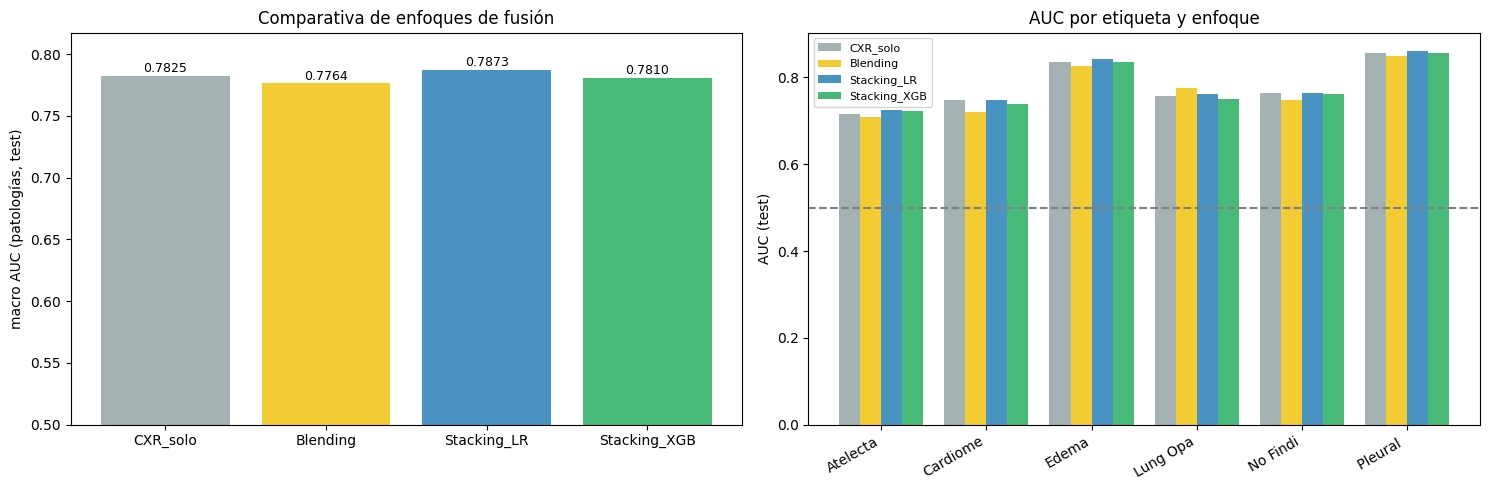

Figura guardada.


In [11]:
# CELDA 11 · GRÁFICA COMPARATIVA (barras macro + por etiqueta)
fig,axes=plt.subplots(1,2,figsize=(15,5))
order=["CXR_solo","Blending","Stacking_LR","Stacking_XGB"]; cols=["#95a5a6","#f1c40f","#2980b9","#27ae60"]
ax=axes[0]; vals=[TESTM[k]["macro_AUC_path"] for k in order]
ax.bar(order,vals,color=cols,alpha=0.85); ax.set_ylim(0.5,max(vals)+0.03); ax.set_ylabel("macro AUC (patologías, test)")
ax.set_title("Comparativa de enfoques de fusión")
for i,v in enumerate(vals): ax.text(i,v+0.003,f"{v:.4f}",ha="center",fontsize=9)
ax=axes[1]; x=np.arange(N_LABELS); wbar=0.2
for i,k in enumerate(order):
    ax.bar(x+(i-1.5)*wbar,[TESTM[k][l]["AUC"] for l in LABELS],wbar,label=k,color=cols[i],alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([l[:8] for l in LABELS],rotation=30,ha="right"); ax.axhline(0.5,color="gray",ls="--")
ax.set_ylabel("AUC (test)"); ax.set_title("AUC por etiqueta y enfoque"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"comparativa_enfoques.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figura guardada.")


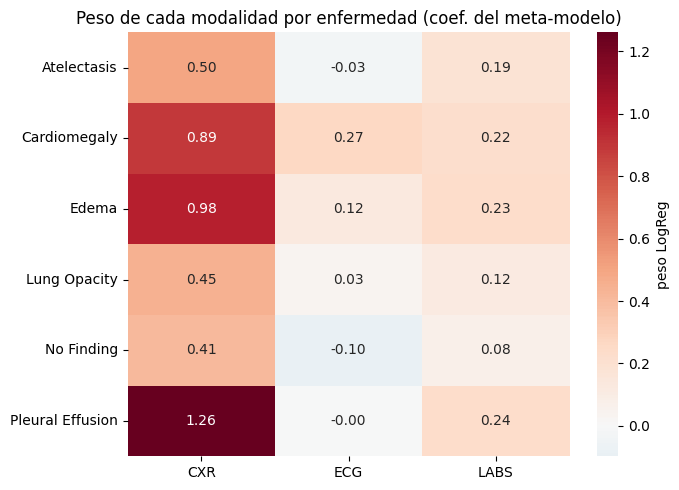

Modalidad dominante por enfermedad (según |peso|):
   Atelectasis        -> CXR (pesos: CXR=+0.50, ECG=-0.03, LABS=+0.19)
   Cardiomegaly       -> CXR (pesos: CXR=+0.89, ECG=+0.27, LABS=+0.22)
   Edema              -> CXR (pesos: CXR=+0.98, ECG=+0.12, LABS=+0.23)
   Lung Opacity       -> CXR (pesos: CXR=+0.45, ECG=+0.03, LABS=+0.12)
   No Finding         -> CXR (pesos: CXR=+0.41, ECG=-0.10, LABS=+0.08)
   Pleural Effusion   -> CXR (pesos: CXR=+1.26, ECG=-0.00, LABS=+0.24)


In [12]:
# CELDA 12 · INTERPRETACIÓN: ¿qué modalidad pesa en cada enfermedad? (coeficientes LogReg)
# Se entrena un LogReg por etiqueta SOLO sobre las 18 probabilidades (sin contexto) para leer pesos limpios.
sc=StandardScaler().fit(Xmeta_oof[:, :18]); Xp=sc.transform(Xmeta_oof[:, :18])
W=np.zeros((N_LABELS,3))  # peso agregado por modalidad y etiqueta
coef_full=np.zeros((N_LABELS,18))
for j,l in enumerate(LABELS):
    sel=m_train[:,j]==1; yj=y_train[sel,j]
    if len(np.unique(yj))<2: continue
    clf=make_lr(bestC).fit(Xp[sel],yj); co=clf.coef_[0]; coef_full[j]=co
    for mi in range(3): W[j,mi]=co[mi*N_LABELS+j]   # peso de la modalidad mi para SU misma etiqueta j
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(W,annot=True,fmt=".2f",cmap="RdBu_r",center=0,xticklabels=MODALITIES,yticklabels=LABELS,ax=ax,cbar_kws={"label":"peso LogReg"})
ax.set_title("Peso de cada modalidad por enfermedad (coef. del meta-modelo)")
plt.tight_layout(); plt.savefig(FIG/"pesos_modalidad_enfermedad.png",dpi=150,bbox_inches="tight"); plt.show()
print("Modalidad dominante por enfermedad (según |peso|):")
for j,l in enumerate(LABELS):
    mi=int(np.argmax(np.abs(W[j]))); print(f"   {l:18s} -> {MODALITIES[mi]} (pesos: "+", ".join(f'{MODALITIES[k]}={W[j,k]:+.2f}' for k in range(3))+")")


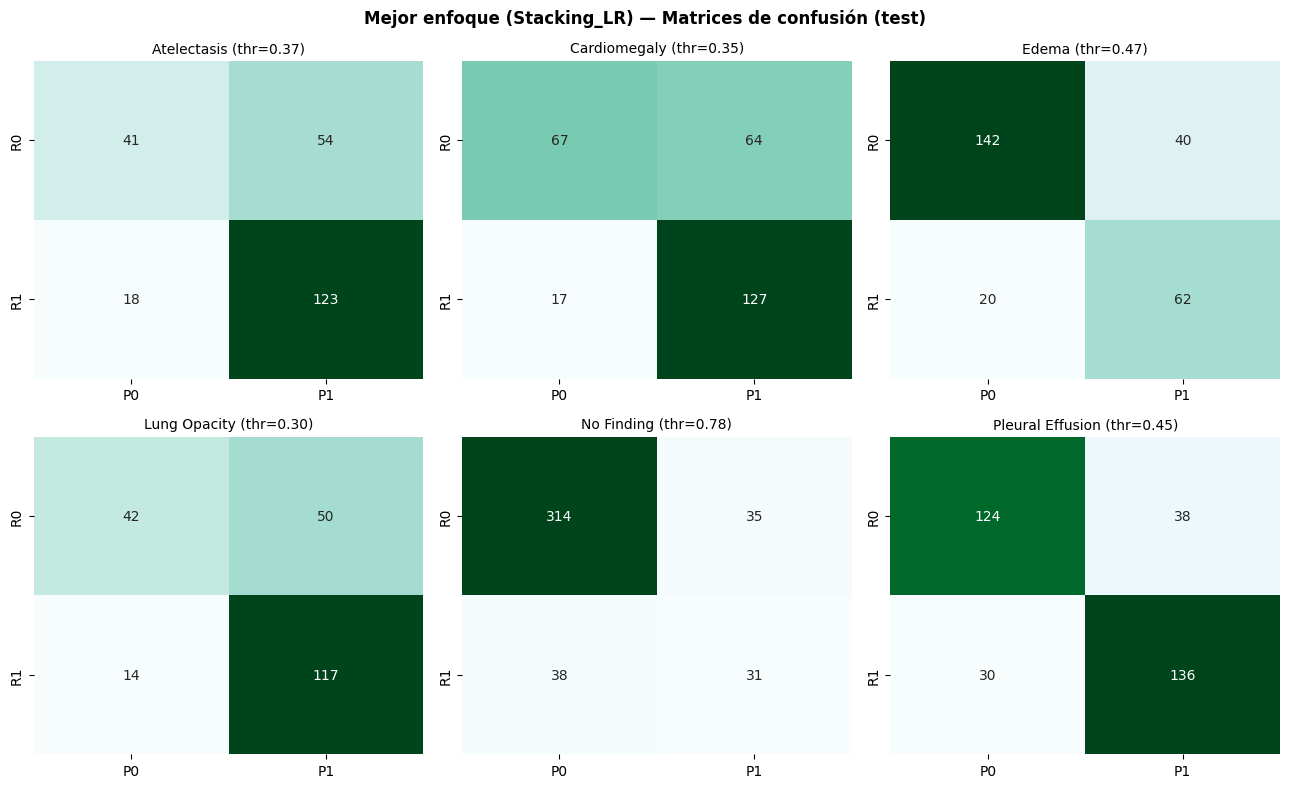

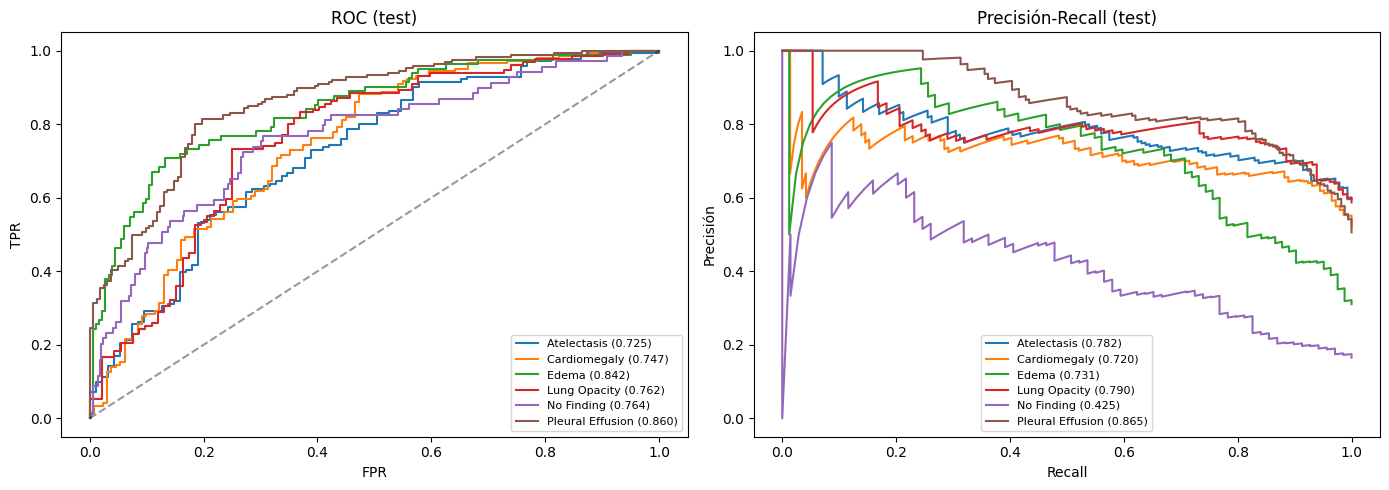

Figuras guardadas en c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_stacking\figuras


In [13]:
# CELDA 13 · MATRICES DE CONFUSIÓN + ROC/PR del mejor enfoque (test)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle(f"Mejor enfoque ({BESTAP}) — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(best_test[s,j]>=best_thr.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1]); sns.heatmap(cm,annot=True,fmt="d",cmap="BuGn",cbar=False,ax=ax,xticklabels=["P0","P1"],yticklabels=["R0","R1"]); ax.set_title(f"{l} (thr={best_thr.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG/"confusion_mejor_enfoque.png",dpi=150,bbox_inches="tight"); plt.show()
fig,axes=plt.subplots(1,2,figsize=(14,5))
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=best_test[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); axes[0].plot(fpr,tpr,label=f"{l} ({TESTM[BESTAP][l]['AUC']:.3f})")
    pr,rc,_=precision_recall_curve(yt,yp); axes[1].plot(rc,pr,label=f"{l} ({TESTM[BESTAP][l]['AP']:.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4); axes[0].set_title("ROC (test)"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)
axes[1].set_title("Precisión-Recall (test)"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisión"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"roc_pr_mejor_enfoque.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figuras guardadas en", FIG)


---
## ✅ Conclusión — Stacking multimodal

Fusiona las predicciones de **CXR (v5), ECG (v3.1) y LABS (blend local)** con un **meta-modelo** que aprende el peso de
cada modalidad por enfermedad. Predicciones **out-of-fold** (sin data leakage), test **limpio**, y comparación de
**dos meta-modelos** (Regresión Logística L2 y XGBoost) frente a **blending** y al **mejor modelo individual**.

**Salidas:** `comparativa_enfoques.csv`, `summary_stacking.json`, `base_preds_*.csv`, y figuras
(comparativa, pesos modalidad×enfermedad, matrices de confusión, ROC/PR).

**Interpretación clave:** el heatmap de pesos muestra **qué modalidad manda en cada hallazgo** (CXR domina; LABS aporta
en Edema/Derrame; ECG aporta algo en Cardiomegaly). La mejora del stacking sobre CXR en solitario suele ser **modesta
(≈0.01-0.03 macro)**, pero el valor metodológico es la **fusión multimodal rigurosa** y su comparación con el blending.
